<a href="https://colab.research.google.com/github/sandeshghimire2/DL_practice/blob/main/Data_agumentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
from google.colab import drive
drive.mount('/content/drive')
import keras
import os

os.makedirs("augmented_images", exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
img = image.load_img("/content/cat.jpeg",target_size=(224,224))

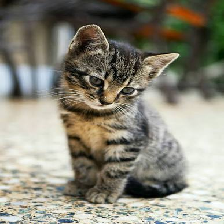

In [11]:
img

In [16]:
img_array = image.img_to_array(img)

# Add batch dimension
img_array = img_array.reshape((1,) + img_array.shape)

In [14]:
img_array.shape

(1, 224, 224, 3)

In [19]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [39]:
i = 0

for batch in datagen.flow(
    img_array,
    batch_size=1,
    save_to_dir="augmented_images",
    save_prefix="aug",
    save_format="jpg"
):
    i += 1
    if i >= 10:
        break

In [29]:
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

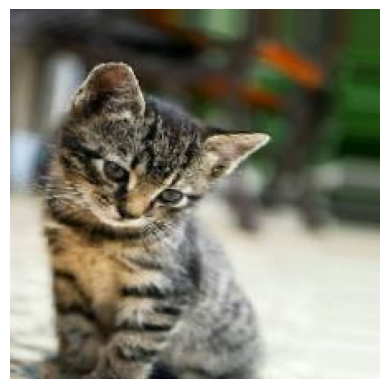

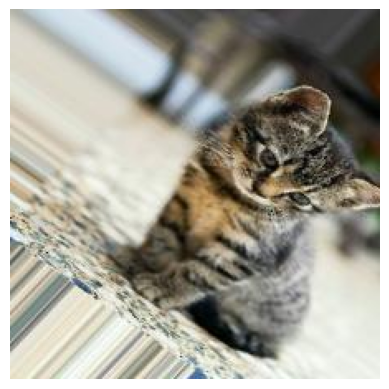

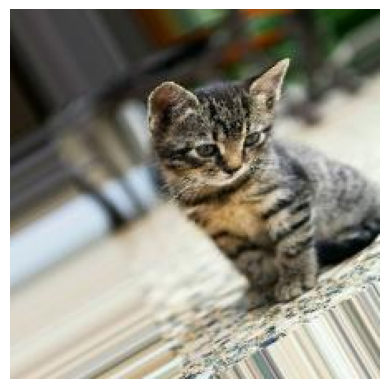

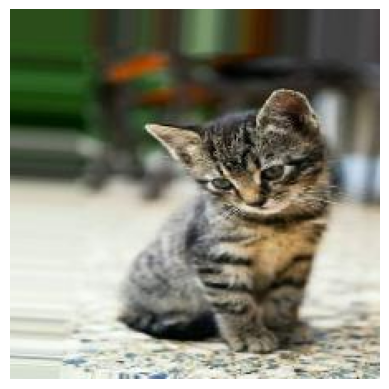

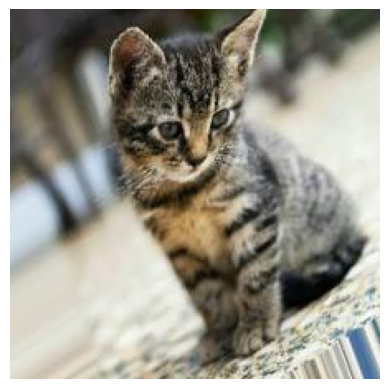

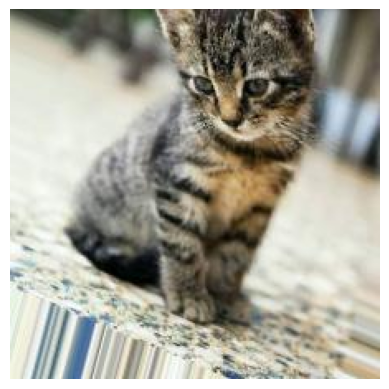

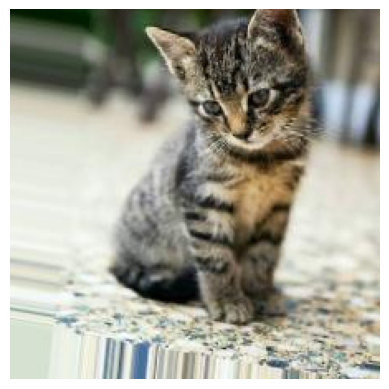

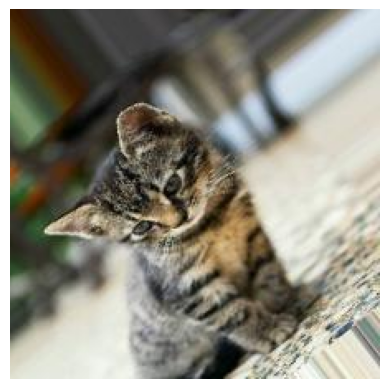

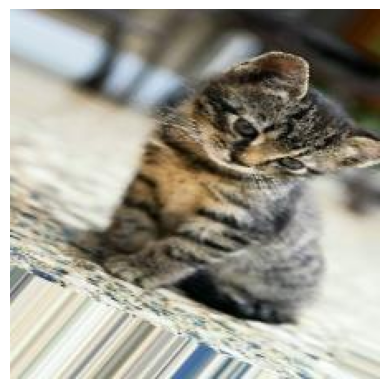

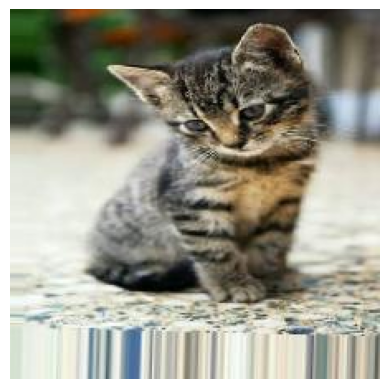

In [30]:
folder = "/content/augmented_images"
for filename in os.listdir(folder):
    img = image.load_img(os.path.join(folder, filename))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [41]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Input folder
input_folder = "/content/augmented_images"

# Output folder
output_folder = "/content/more_augmented_images"
os.makedirs(output_folder, exist_ok=True)

# Augmentation
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Augment every image
for filename in os.listdir(input_folder):

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        img = image.load_img(
            os.path.join(input_folder, filename),
            target_size=(224, 224)
        )

        img_array = image.img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)

        i = 0

        for batch in datagen.flow(
            img_array,
            batch_size=1,
            save_to_dir=output_folder,
            save_prefix="aug",
            save_format="jpg"
        ):
            i += 1

            if i >= 10:
                break